# 07 - Full Data CV Error Analysis

## Objective

Analyze the prediction errors of the validated LightGBM model using the same walk-forward cross-validation setup from NB5 full data.

This notebook focuses on model diagnosis, not on training a new model.

Main goals:

- analyze errors on unseen validation folds
- identify difficult stores and product families
- compare weekday vs weekend performance
- inspect the impact of promotions and high-sales periods
- extract actionable insights for future improvements

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor

sys.path.append(str(Path().resolve().parent))

from src.features import add_baseline_features, add_advanced_features, encode_family
from src.metrics import evaluate_regression
from src.split import build_walk_forward_folds, split_by_fold
from src.error_analysis import (
    add_error_columns,
    add_analysis_labels,
    summarize_errors,
    add_sales_bins,
    get_worst_predictions,
)

## Setup

Use the full dataset and the same validated advanced feature pipeline from NB5 full data.

In [2]:
SEED = 42
DATA_DIR = Path("../data")

USE_FULL_DATA = True

ARTIFACTS_DIR = Path("../artifacts/nb7_full_data_cv_error_analysis")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

ERRORS_PATH = ARTIFACTS_DIR / "nb7_errors_df.csv"
FOLD_METRICS_PATH = ARTIFACTS_DIR / "nb7_fold_metrics.csv"

FORCE_RETRAIN = False

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data


## Load data

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train range:", train["date"].min(), "->", train["date"].max())
print("Test range:", test["date"].min(), "->", test["date"].max())

Train shape: (3000888, 6)
Test shape: (28512, 5)
Train range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


## Preprocessing and feature engineering

Rebuild the same advanced feature set used in NB5 full data.

In [4]:
train = train.sort_values(["store_nbr", "family", "date"]).copy()
test = test.sort_values(["store_nbr", "family", "date"]).copy()

for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

advanced_train = add_baseline_features(train)
advanced_train = add_advanced_features(advanced_train)
advanced_train = advanced_train.dropna().copy()

advanced_train, advanced_test, family_mapping = encode_family(advanced_train, test)

advanced_features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "trend_1_7",
    "promo_last_7",
]

print("Advanced train shape:", advanced_train.shape)
print("Date range:", advanced_train["date"].min(), "->", advanced_train["date"].max())
print("Number of features:", len(advanced_features))

Advanced train shape: (2975940, 19)
Date range: 2013-01-15 00:00:00 -> 2017-08-15 00:00:00
Number of features: 16


## Rebuild NB5 full-data validation folds

Use the same recent anchored walk-forward validation strategy from NB5 full data.

In [5]:
N_FOLDS = 4
VAL_SIZE = 28

folds = build_walk_forward_folds(
    df=advanced_train,
    n_folds=N_FOLDS,
    val_size=VAL_SIZE,
)

folds_df = pd.DataFrame(folds)
display(folds_df)

,fold,train_end,val_start,val_end
0,1,2017-04-25,2017-04-26,2017-05-23
1,2,2017-05-23,2017-05-24,2017-06-20
2,3,2017-06-20,2017-06-21,2017-07-18
3,4,2017-07-18,2017-07-19,2017-08-15


## Generate validation predictions across folds

Train the model on each fold and collect predictions only on unseen validation windows.

These predictions are used for error analysis.

In [6]:
all_errors = []
fold_metrics = []

if ERRORS_PATH.exists() and FOLD_METRICS_PATH.exists() and not FORCE_RETRAIN:
    print("Loading cached NB7 validation artifacts...")
    errors_df = pd.read_csv(ERRORS_PATH, parse_dates=["date"])
    fold_metrics_df = pd.read_csv(FOLD_METRICS_PATH)

else:
    print("Training fold models and generating validation predictions...")

    for fold_info in folds:
        fold = fold_info["fold"]

        train_fold, val_fold, X_train, y_train, X_val, y_val = split_by_fold(
            df=advanced_train,
            features=advanced_features,
            fold_info=fold_info,
        )

        model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=SEED,
            n_jobs=-1,
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)

        metrics = evaluate_regression(y_val, y_pred)
        metrics["fold"] = fold
        fold_metrics.append(metrics)

        fold_errors = add_error_columns(
            val_data=val_fold,
            y_pred=y_pred,
            fold=fold,
        )

        all_errors.append(fold_errors)

        print(
            f"Fold {fold} | "
            f"RMSLE={metrics['rmsle']:.6f} | "
            f"MAE={metrics['mae']:.3f} | "
            f"RMSE={metrics['rmse']:.3f} | "
            f"R2={metrics['r2']:.6f}"
        )

    errors_df = pd.concat(all_errors, ignore_index=True)
    fold_metrics_df = pd.DataFrame(fold_metrics)

    errors_df.to_csv(ERRORS_PATH, index=False)
    fold_metrics_df.to_csv(FOLD_METRICS_PATH, index=False)

    print("Saved cached artifacts:")
    print(ERRORS_PATH)
    print(FOLD_METRICS_PATH)

print("Errors dataframe shape:", errors_df.shape)
display(fold_metrics_df)
display(errors_df.head())

Training fold models and generating validation predictions...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115555 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2189
[LightGBM] [Info] Number of data points in the train set: 2776356, number of used features: 16
[LightGBM] [Info] Start training from score 350.248207
Fold 1 | RMSLE=0.600119 | MAE=78.626 | RMSE=298.492 | R2=0.952325
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.101924 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2191
[LightGBM] [Info] Number of data points in the train set: 2826252, number of used features: 16
[LightGBM] [Info] Start training from score 352.734481
Fold 2 | RMSLE=0.614805 | MAE=71.947 | RMSE=267.177 

,rmsle,mae,rmse,r2,fold
0,0.600119,78.625545,298.492309,0.952325,1
1,0.614805,71.947313,267.177052,0.962979,2
2,0.579065,58.081478,211.644822,0.974482,3
3,0.605530,65.136453,217.512603,0.970692,4


,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek,...,rolling_mean_7,rolling_std_7,rolling_mean_14,trend_1_7,promo_last_7,fold,y_pred,error,abs_error,squared_error
0,2801304,2017-04-26,1,0,2.0,0,2017,4,26,2,...,3.714286,1.799471,3.357143,-1.0,0.0,1,3.649558,-1.649558,1.649558,2.721041
1,2803086,2017-04-27,1,0,8.0,0,2017,4,27,3,...,3.428571,1.902379,3.285714,0.0,0.0,1,3.300097,4.699903,4.699903,22.089092
2,2804868,2017-04-28,1,0,3.0,0,2017,4,28,4,...,4.285714,2.429972,3.214286,3.0,0.0,1,4.817097,-1.817097,1.817097,3.301843
3,2806650,2017-04-29,1,0,2.0,0,2017,4,29,5,...,4.000000,2.449490,3.357143,-2.0,0.0,1,5.038323,-3.038323,3.038323,9.231405
4,2808432,2017-04-30,1,0,3.0,0,2017,4,30,6,...,3.571429,2.507133,3.285714,1.0,0.0,1,3.085517,-0.085517,0.085517,0.007313


## Add readable labels

In [7]:
errors_df = add_analysis_labels(
    errors_df=errors_df,
    family_mapping=family_mapping,
)

display(errors_df[
    [
        "date",
        "fold",
        "store_nbr",
        "family",
        "family_name",
        "sales",
        "y_pred",
        "error",
        "abs_error",
        "is_weekend",
        "onpromotion",
        "promo_flag",
    ]
].head())

,date,fold,store_nbr,family,family_name,sales,y_pred,error,abs_error,is_weekend,onpromotion,promo_flag
0,2017-04-26,1,1,0,AUTOMOTIVE,2.0,3.649558,-1.649558,1.649558,0,0,0
1,2017-04-27,1,1,0,AUTOMOTIVE,8.0,3.300097,4.699903,4.699903,0,0,0
2,2017-04-28,1,1,0,AUTOMOTIVE,3.0,4.817097,-1.817097,1.817097,0,0,0
3,2017-04-29,1,1,0,AUTOMOTIVE,2.0,5.038323,-3.038323,3.038323,1,0,0
4,2017-04-30,1,1,0,AUTOMOTIVE,3.0,3.085517,-0.085517,0.085517,1,0,0


## Global error summary

In [22]:
global_summary = summarize_errors(errors_df)

display(global_summary)

,mean_abs_error,median_abs_error,mean_error,max_abs_error,n_predictions
0,68.447697,7.557026,-1.956485,13480.210935,199584


## Error by fold

Check whether some validation windows are more difficult than others.

,fold,mean_abs_error,median_abs_error,mean_error,max_abs_error,count
0,1,78.625545,7.963387,3.578185,11528.539988,49896
1,2,71.947313,7.680752,0.693924,10364.383153,49896
2,3,58.081478,7.091330,-5.351896,13480.210935,49896
3,4,65.136453,7.353716,-6.746151,5006.164175,49896


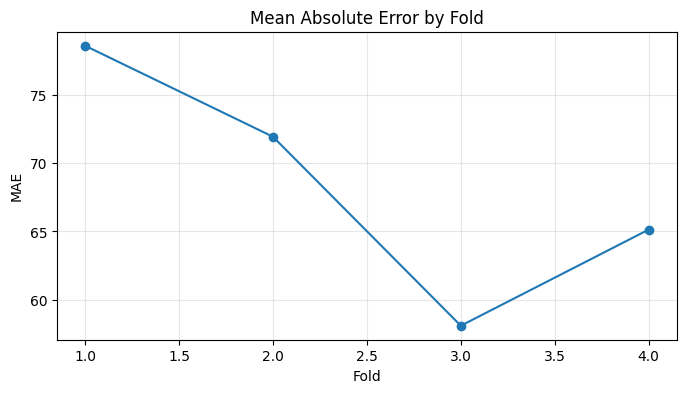

In [20]:
error_by_fold = (
    errors_df
    .groupby("fold")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_error=("error", "mean"),
        max_abs_error=("abs_error", "max"),
        count=("abs_error", "size")
    )
    .reset_index()
)

display(error_by_fold)

plt.figure(figsize=(8, 4))
plt.plot(error_by_fold["fold"], error_by_fold["mean_abs_error"], marker="o")
plt.title("Mean Absolute Error by Fold")
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.show()

## Weekday vs weekend errors

,mean_abs_error,median_abs_error,mean_error,count
Weekday,60.949258,7.060692,-0.000277,142560
Weekend,87.193795,8.990746,-6.847005,57024


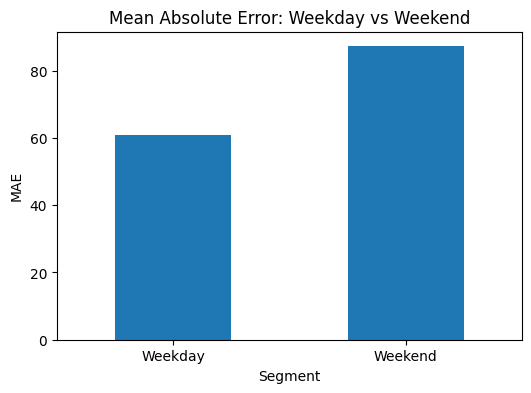

In [10]:
error_weekend = (
    errors_df
    .groupby("is_weekend")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_error=("error", "mean"),
        count=("abs_error", "size")
    )
)

error_weekend.index = ["Weekday", "Weekend"]

display(error_weekend)

plt.figure(figsize=(6, 4))
error_weekend["mean_abs_error"].plot(kind="bar")
plt.title("Mean Absolute Error: Weekday vs Weekend")
plt.xlabel("Segment")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.show()

## Error by store

Identify stores where the model struggles most.

,mean_abs_error,median_abs_error,mean_error,mean_sales,count
store_nbr,,,,,
45,140.506839,17.293621,14.361620,1270.376021,3696
44,140.036569,18.445609,10.303226,1378.046180,3696
47,135.398265,16.215222,6.905692,1180.680599,3696
46,129.401302,12.759762,5.663877,955.984928,3696
49,115.858975,15.665861,0.801115,1086.616142,3696
3,112.570512,15.777898,1.319877,1126.727840,3696
48,107.334074,11.032283,-6.794538,782.327363,3696
51,103.700428,11.812721,2.682314,733.280323,3696
52,92.868021,12.372135,-6.404657,686.314663,3696


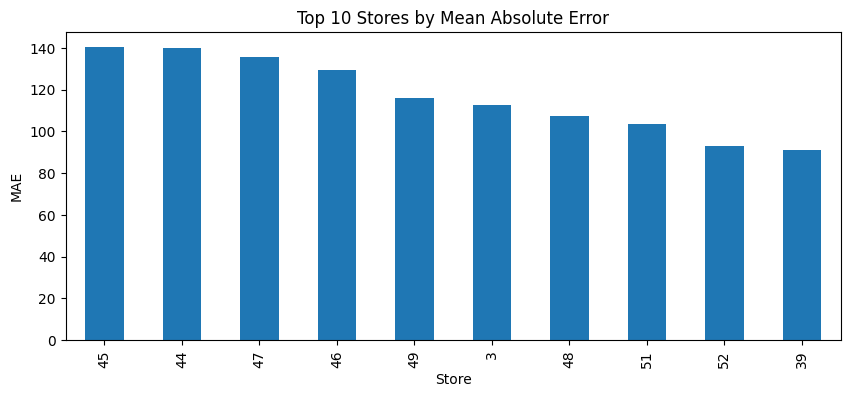

In [11]:
error_by_store = (
    errors_df
    .groupby("store_nbr")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_error=("error", "mean"),
        mean_sales=("sales", "mean"),
        count=("abs_error", "size")
    )
    .sort_values("mean_abs_error", ascending=False)
)

display(error_by_store.head(10))

plt.figure(figsize=(10, 4))
error_by_store["mean_abs_error"].head(10).plot(kind="bar")
plt.title("Top 10 Stores by Mean Absolute Error")
plt.xlabel("Store")
plt.ylabel("MAE")
plt.show()

## 11. Error by product family

Identify product families that are harder to forecast.

,mean_abs_error,median_abs_error,mean_error,mean_sales,count
family_name,,,,,
GROCERY I,557.568735,359.642689,35.306424,4710.318764,6048
BEVERAGES,483.173018,298.287127,23.469824,3577.994874,6048
CLEANING,265.475442,145.296153,-27.507488,1304.857804,6048
PRODUCE,255.465910,142.264510,-13.508715,2398.389518,6048
DAIRY,114.716699,72.811426,-26.581783,920.617063,6048
MEATS,69.547506,38.548874,-12.004379,378.751890,6048
BREAD/BAKERY,68.578724,43.346411,0.944379,555.804435,6048
POULTRY,63.158751,33.974060,-4.231159,396.548096,6048
PERSONAL CARE,59.391677,37.118158,-5.934853,318.021495,6048


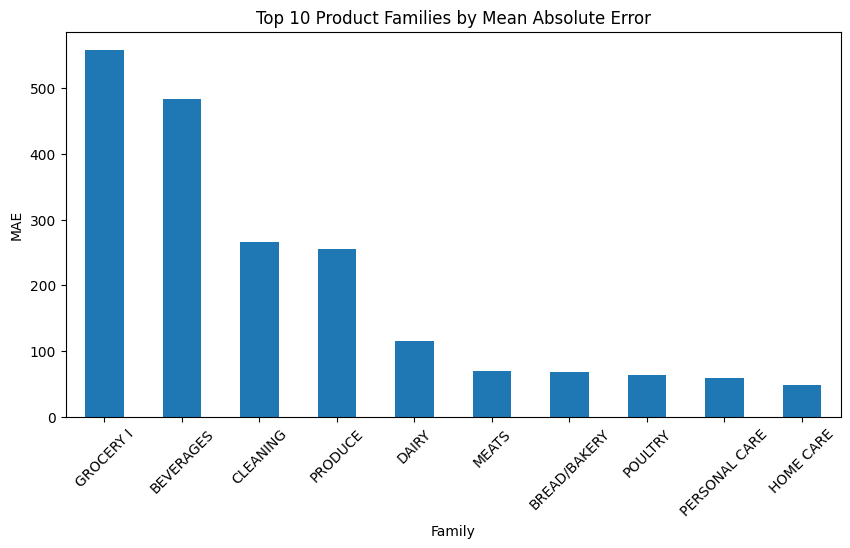

In [12]:
error_by_family = (
    errors_df
    .groupby("family_name")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_error=("error", "mean"),
        mean_sales=("sales", "mean"),
        count=("abs_error", "size")
    )
    .sort_values("mean_abs_error", ascending=False)
)

display(error_by_family.head(10))

plt.figure(figsize=(10, 5))
error_by_family["mean_abs_error"].head(10).plot(kind="bar")
plt.title("Top 10 Product Families by Mean Absolute Error")
plt.xlabel("Family")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

## Error by promotion flag

Check whether promoted items are harder to forecast.

,mean_abs_error,median_abs_error,mean_error,mean_sales,count
No promotion,11.544683,2.699437,-1.795149,60.816486,109126
Promotion,137.093901,35.640246,-2.151115,991.797796,90458


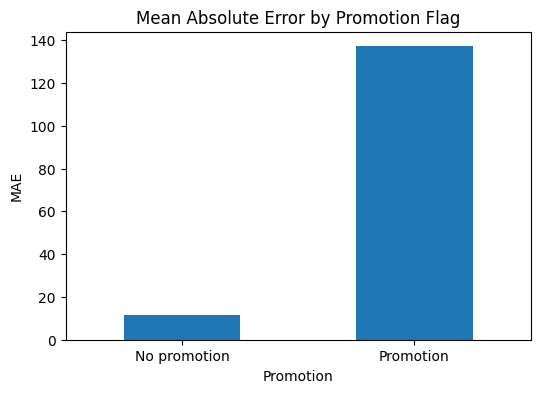

In [13]:
error_by_promo = (
    errors_df
    .groupby("promo_flag")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_error=("error", "mean"),
        mean_sales=("sales", "mean"),
        count=("abs_error", "size")
    )
)

error_by_promo.index = ["No promotion", "Promotion"]

display(error_by_promo)

plt.figure(figsize=(6, 4))
error_by_promo["mean_abs_error"].plot(kind="bar")
plt.title("Mean Absolute Error by Promotion Flag")
plt.xlabel("Promotion")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.show()

## Error by sales volume

Check whether the model struggles more on low-sales or high-sales observations.

,mean_abs_error,median_abs_error,mean_error,mean_sales,count
sales_bin,,,,,
Low,2.388066,1.812428,-2.269002,0.863003,49896
Medium-low,5.859511,3.718225,-1.544347,12.554752,49896
Medium-high,27.546484,18.535107,-7.839817,120.892900,49896
High,237.996728,103.644064,3.827228,1796.760069,49896


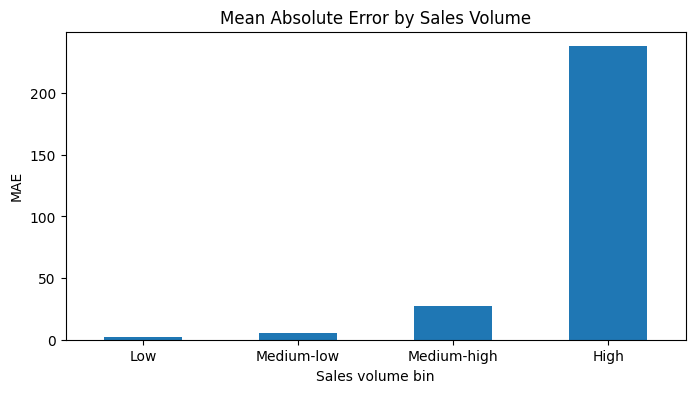

In [14]:
errors_df["sales_bin"] = pd.qcut(
    errors_df["sales"].rank(method="first"),
    q=4,
    labels=["Low", "Medium-low", "Medium-high", "High"]
)

error_by_sales_bin = (
    errors_df
    .groupby("sales_bin")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_error=("error", "mean"),
        mean_sales=("sales", "mean"),
        count=("abs_error", "size")
    )
)

display(error_by_sales_bin)

plt.figure(figsize=(8, 4))
error_by_sales_bin["mean_abs_error"].plot(kind="bar")
plt.title("Mean Absolute Error by Sales Volume")
plt.xlabel("Sales volume bin")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.show()

## Worst predictions

Inspect the largest absolute errors to understand extreme failure cases.

In [15]:
worst_predictions = (
    errors_df
    .sort_values("abs_error", ascending=False)
    .head(20)
)

display(worst_predictions[[
    "date",
    "fold",
    "store_nbr",
    "family_name",
    "sales",
    "y_pred",
    "error",
    "abs_error",
    "dayofweek",
    "is_weekend",
    "onpromotion",
    "promo_last_7",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "trend_1_7"
]])

,date,fold,store_nbr,family_name,sales,y_pred,error,abs_error,dayofweek,is_weekend,onpromotion,promo_last_7,lag_1,lag_7,rolling_mean_7,trend_1_7
148852,2017-06-25,3,54,BEVERAGES,17614.000,4133.789065,13480.210935,13480.210935,6,1,30,134.0,2043.000,8310.00,2950.857143,-6267.000
28067,2017-05-07,1,31,GROCERY I,16992.516,5463.976012,11528.539988,11528.539988,6,1,49,452.0,5195.875,6117.32,4904.650571,-921.445
14056,2017-04-26,1,16,CLEANING,11377.000,628.881120,10748.118880,10748.118880,2,0,44,256.0,726.000,466.00,716.285714,260.000
49329,2017-05-17,1,54,GROCERY I,13533.000,2792.442471,10740.557529,10740.557529,2,0,41,352.0,3251.000,2215.00,3675.571429,1036.000
28987,2017-05-03,1,32,GROCERY I,12598.000,1992.223764,10605.776236,10605.776236,2,0,57,357.0,1927.000,1766.00,1644.571429,161.000
98970,2017-06-11,2,54,BEVERAGES,13889.000,3524.616847,10364.383153,10364.383153,6,1,26,176.0,2426.000,4605.00,3748.000000,-2179.000
43769,2017-05-01,1,48,GROCERY I,20073.000,9912.009353,10160.990647,10160.990647,0,0,89,778.0,14313.000,6994.00,8314.000000,7319.000
126803,2017-07-10,3,30,CLEANING,10392.000,557.793105,9834.206895,9834.206895,0,0,23,194.0,462.000,548.00,892.285714,-86.000
42845,2017-05-01,1,47,GROCERY I,21021.000,11338.293264,9682.706736,9682.706736,0,0,97,795.0,14368.000,8974.00,9993.285714,5394.000
40997,2017-05-01,1,45,GROCERY I,21270.000,11927.580533,9342.419467,9342.419467,0,0,91,749.0,15309.000,10223.00,10813.428571,5086.000


## Daily error trend

Aggregate errors by date to detect difficult periods.

,date,mean_abs_error,mean_error,total_sales,count
0,2017-04-26,57.801939,22.402025,7.811593e+05,1782
1,2017-04-27,47.144120,-20.704481,6.249100e+05,1782
2,2017-04-28,55.166787,25.206505,7.976366e+05,1782
3,2017-04-29,80.259544,41.114037,1.068280e+06,1782
4,2017-04-30,104.826066,-82.479140,1.041249e+06,1782


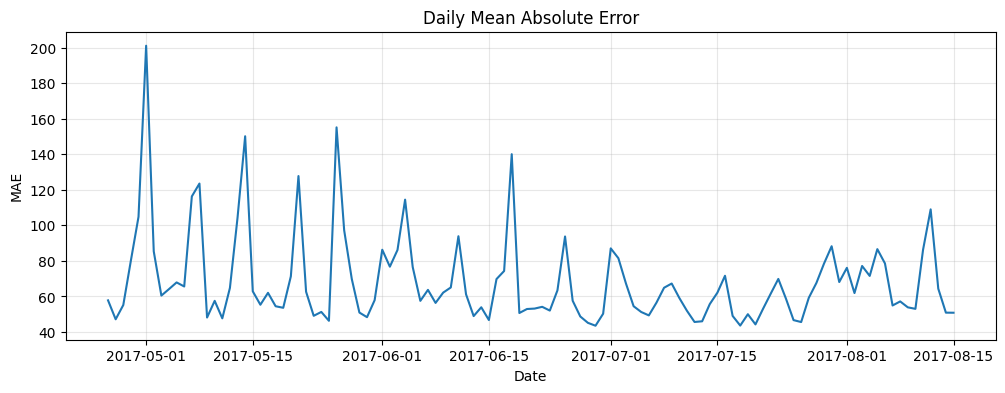

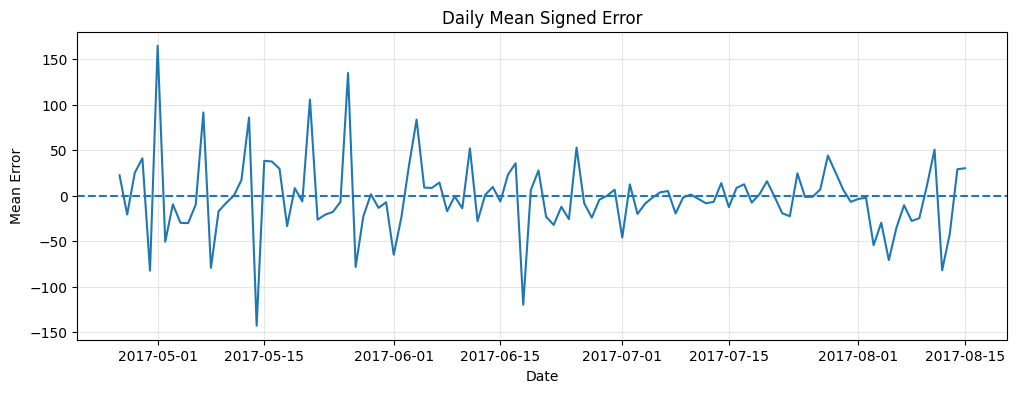

In [16]:
daily_error = (
    errors_df
    .groupby("date")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        mean_error=("error", "mean"),
        total_sales=("sales", "sum"),
        count=("abs_error", "size")
    )
    .reset_index()
)

display(daily_error.head())

plt.figure(figsize=(12, 4))
plt.plot(daily_error["date"], daily_error["mean_abs_error"])
plt.title("Daily Mean Absolute Error")
plt.xlabel("Date")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(daily_error["date"], daily_error["mean_error"])
plt.axhline(0, linestyle="--")
plt.title("Daily Mean Signed Error")
plt.xlabel("Date")
plt.ylabel("Mean Error")
plt.grid(True, alpha=0.3)
plt.show()

## Key Findings

The error analysis reveals several important and quantifiable patterns:

- The model shows stable performance across folds, with MAE ranging from ~58 to ~78, indicating good generalization over time.

- Errors are significantly higher during weekends:
  - Weekday MAE ≈ 60.9
  - Weekend MAE ≈ 87.2  
  This suggests that weekend demand is more volatile and harder to predict.

- Promotions have a strong impact on prediction errors:
  - No promotion MAE ≈ 11.5
  - Promotion MAE ≈ 137.1  
  This indicates that promotions introduce sharp, non-linear changes in demand that are not fully captured by current features.

- Error increases dramatically with sales volume:
  - Low sales MAE ≈ 2.4
  - High sales MAE ≈ 238.0  
  The model struggles significantly with high-demand spikes.

- Some product families are particularly difficult to forecast:
  - GROCERY I MAE ≈ 557
  - BEVERAGES MAE ≈ 483  
  These categories show high variability and complex demand patterns.

- Certain stores also exhibit consistently higher errors, suggesting heterogeneous behavior across locations.

---

### Overall interpretation

The model provides stable and consistent performance, but struggles in scenarios characterized by:

- high variability (promotions, weekends)
- large demand values (high sales)
- complex product categories (e.g., grocery)

These findings highlight that the current feature set captures general trends well, but is insufficient to model extreme or non-linear behaviors.

From a business perspective, these errors are critical, as the largest mistakes occur during high-revenue situations (promotions and high sales), where accurate forecasting is most important.

These findings suggest that future improvements should focus on modeling promotions and high-demand spikes more effectively.

In [17]:
top_store = error_by_store.index[0]
top_store_mae = error_by_store.iloc[0]["mean_abs_error"]

top_family = error_by_family.index[0]
top_family_mae = error_by_family.iloc[0]["mean_abs_error"]

weekend_mae = error_weekend.loc["Weekend", "mean_abs_error"]
weekday_mae = error_weekend.loc["Weekday", "mean_abs_error"]

promo_mae = error_by_promo.loc["Promotion", "mean_abs_error"]
no_promo_mae = error_by_promo.loc["No promotion", "mean_abs_error"]

high_sales_mae = error_by_sales_bin.loc["High", "mean_abs_error"]
low_sales_mae = error_by_sales_bin.loc["Low", "mean_abs_error"]

print("Key diagnostic findings")
print("-----------------------")
print(f"Worst store by MAE: {top_store} | MAE={top_store_mae:.2f}")
print(f"Worst family by MAE: {top_family} | MAE={top_family_mae:.2f}")
print(f"Weekday MAE: {weekday_mae:.2f}")
print(f"Weekend MAE: {weekend_mae:.2f}")
print(f"No promotion MAE: {no_promo_mae:.2f}")
print(f"Promotion MAE: {promo_mae:.2f}")
print(f"Low sales MAE: {low_sales_mae:.2f}")
print(f"High sales MAE: {high_sales_mae:.2f}")

Key diagnostic findings
-----------------------
Worst store by MAE: 45 | MAE=140.51
Worst family by MAE: GROCERY I | MAE=557.57
Weekday MAE: 60.95
Weekend MAE: 87.19
No promotion MAE: 11.54
Promotion MAE: 137.09
Low sales MAE: 2.39
High sales MAE: 238.00


## Conclusion

This notebook performs a diagnostic analysis of the final validated LightGBM forecasting pipeline.

Main findings should focus on:

- whether errors are concentrated in specific stores
- whether some product families are systematically harder to forecast
- whether weekends or promotions introduce higher uncertainty
- whether high-sales observations generate larger absolute errors
- whether errors are stable across validation folds

This analysis does not change the final model.

Its purpose is to understand model behavior and identify future improvement directions.

Possible next improvements:

- better promotion features
- store-level or family-level specialized models
- holiday/event features
- hierarchical forecasting
- monitoring of high-error segments

Trade-off:
More complex features may reduce generalization or increase training cost.